In [2]:
import pandas as pd
# from func_utils.utils import save_tocsv

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from dotenv import load_dotenv
import os
import mlflow



# Collect data

### Collect prod data (target)

In [3]:
data_prod_path = '../../data/prod/eCO2mix_RTE_Auvergne-Rhone-Alpes_cleaned.csv'

# read csv
df_prod = pd.read_csv(data_prod_path)
data_prod = df_prod.copy()

# formatting the date for future data merge operations
data_prod['Time'] = pd.to_datetime(data_prod['date']+" "+data_prod['heures'])


### Collect Openweather data

In [6]:
data_weather_path = '../../data/openweathermap/merge_openweathermap_cleaned.csv'

# read csv
df_weather = pd.read_csv(data_weather_path)
data_weather = df_weather.copy()

# formatting the date for future data merge operations
data_weather['Time'] = pd.to_datetime(data_weather['dt'])


### Merge data (inner merge)

In [ ]:
# group ytdry the weather data by the time variable to aggregate the images data (5 cities in AuRA)
weather_columns_to_use = ['temp', 'pressure', 'humidity', 'clouds']
data_weather_grouped = data_weather.groupby('Time')[weather_columns_to_use].mean().reset_index()

# select columns from production data
prod_columns_to_use = ['Time', 'solaire', 'tco_solaire_(%)', 'tch_solaire_(%)']
data_prod_limited = data_prod[prod_columns_to_use]

merged_data = data_weather_grouped.merge(data_prod_limited, on='Time', how='inner')
# save_tocsv(merged_data, '../../data/compiled_data/weather_only_data.csv')


In [31]:
merged_data.head()

,Time,temp,pressure,humidity,clouds,solaire,tco_solaire_(%),tch_solaire_(%)
0,2021-01-09 11:00:00,0.778,1017.2,71.0,76.6,158.0,1.54,13.28
1,2021-01-10 11:00:00,0.264,1018.6,70.4,67.6,179.0,1.78,15.04
2,2021-01-11 11:00:00,-0.756,1024.2,72.2,36.6,200.0,1.73,16.81
3,2021-01-12 11:00:00,2.110,1025.0,78.4,92.6,110.0,0.94,9.24
4,2021-01-13 11:00:00,7.260,1024.6,91.6,84.4,93.0,0.87,7.82


# Visualisation

In [34]:
px.scatter(merged_data, x='Time', y=['temp', 'humidity', 'clouds', 'tch_solaire_(%)'])

In [35]:
px.scatter(merged_data, x='clouds', y='tch_solaire_(%)', trendline='ols')

In [36]:
px.scatter(merged_data, x='humidity', y='tch_solaire_(%)', trendline='ols')

In [38]:
px.scatter(merged_data, x='temp', y='tch_solaire_(%)', trendline='ols')

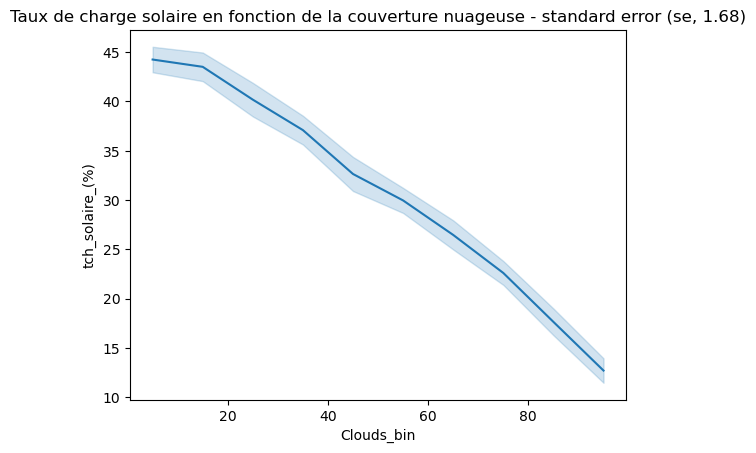

In [40]:
merged_data['Clouds_bin'] = pd.cut(merged_data['clouds'], bins=10, labels=range(5,100,10))
sns.lineplot(merged_data, x='Clouds_bin', y='tch_solaire_(%)', errorbar=('se',1.68))
plt.title("Taux de charge solaire en fonction de la couverture nuageuse - standard error (se, 1.68)")
plt.show()

# Modeles

In [43]:
target = 'tch_solaire_(%)'
# possibles target : ['solaire', 'tco_solaire_(%)', 'tch_solaire_(%)']
y = merged_data[target].to_numpy() #target

features = ['temp', 'pressure', 'humidity', 'clouds']
# possibles features : ['Time', 'temp', 'pressure', 'humidity', 'clouds']
x = merged_data[features] #features


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Preprocessing
sc = StandardScaler()
sc.fit(x_train)

x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

# pour enregistrer dans MLFlow
load_dotenv()

os.environ["APP_URI"] = "https://renergies99-mlflow.hf.space/"
EXPERIMENT_NAME="first_weather_models"

mlflow.set_tracking_uri(os.environ["APP_URI"])
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

mlflow.sklearn.autolog()

# model 1
run_description = f"""
colonnes utilisées : {features}
\n target : {target}
"""

with mlflow.start_run(experiment_id = experiment.experiment_id, description=run_description):
    model = LinearRegression()
    model.fit(x_train, y_train)

    score = model.score(x_test, y_test)
    
    mlflow.log_metric("ScoreR2", score)
    mlflow.sklearn.log_model(model, "model")

print('model_score_train: ', model.score(x_train,y_train))
print('model_score_test: ', model.score(x_test,y_test))


2025/11/14 18:34:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run burly-quail-444 at: https://renergies99-mlflow.hf.space/#/experiments/4/runs/d81138d3368d4c048bafd9c7fefd70d5
🧪 View experiment at: https://renergies99-mlflow.hf.space/#/experiments/4
model_score_train:  0.6520711757287437
model_score_test:  0.630038867720601
